In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_store_inventory.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day

In [5]:
df.drop(["Date"], axis=1, inplace=True)

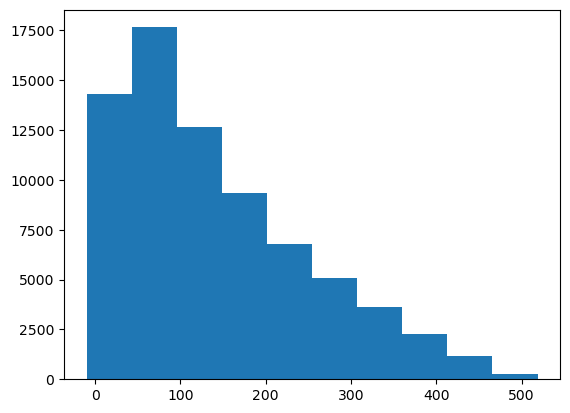

In [6]:
plt.hist(df["Demand Forecast"])
plt.show()

In [7]:
%matplotlib inline

In [8]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
print(numeric_df.shape)
print(numeric_df.head())

(73100, 8)
   Inventory Level  Units Sold  Units Ordered  Demand Forecast  Price  \
0              231         127             55           135.47  33.50   
1              204         150             66           144.04  63.01   
2              102          65             51            74.02  27.99   
3              469          61            164            62.18  32.72   
4              166          14            135             9.26  73.64   

   Discount  Holiday/Promotion  Competitor Pricing  
0        20                  0               29.69  
1        20                  0               66.16  
2        10                  1               31.32  
3        10                  1               34.74  
4         0                  0               68.95  


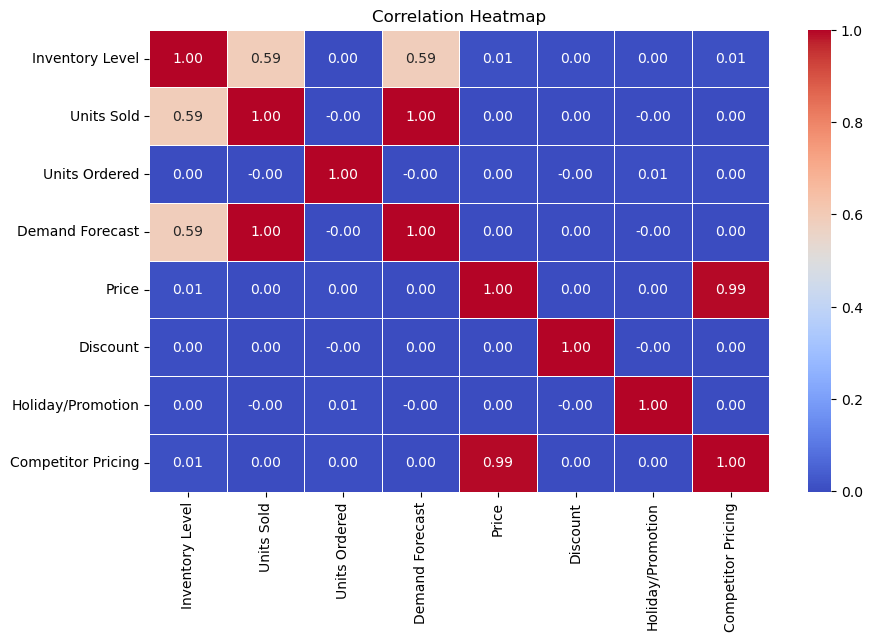

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True, # show values
    fmt=".2f", # 2 decimal
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

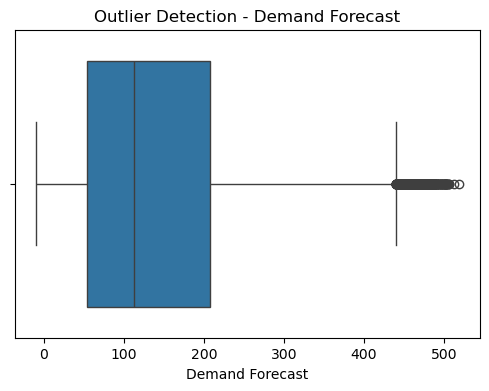

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Demand Forecast"])
plt.title("Outlier Detection - Demand Forecast")
plt.show()

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df.drop("Demand Forecast", axis=1)
y = df["Demand Forecast"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.9934085414238985
MAE: 7.594324924760601


In [16]:

import pickle

pickle.dump(model, open("demand_model.pkl", "wb"))